# COMP662 Assignment 1 — Synthetic Dataset Generation

**Student ID:** 1173808  
**Dataset:** `train.csv` (Dried Bean Classification)  
**Primary metric:** macro-F1  
**Secondary metric:** accuracy

## ENV & Libs Setup

In [18]:
from pathlib import Path
import random
import time
setup_started = time.perf_counter()

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Image, display
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.nn import functional as F

SEED = 42
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE.type == "cuda":
    torch.cuda.manual_seed_all(SEED)
else:
    torch.set_num_threads(1)

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
KAGGLE_ROOT = Path("/kaggle")
kaggle_data = sorted((KAGGLE_ROOT / "input").rglob("train.csv")) if KAGGLE_ROOT.is_dir() else []
DATA_PATH = kaggle_data[0] if kaggle_data else ROOT / "data" / "train.csv"
OUTPUT_DATA = ROOT / "data"
FIGURES = ROOT / "figures"
MODELS = ROOT / "models"
OUTPUT_DATA.mkdir(exist_ok=True)
FIGURES.mkdir(exist_ok=True)
MODELS.mkdir(exist_ok=True)

if DEVICE.type == "cuda":
    RUNTIME_DEVICE = f"{torch.cuda.get_device_name(0)} x{torch.cuda.device_count()}"
elif DEVICE.type == "mps":
    RUNTIME_DEVICE = "Apple Silicon MPS"
else:
    RUNTIME_DEVICE = "CPU"

def format_decimal(value):
    return np.format_float_positional(float(value), unique=True, trim="-")

def log_cell(name, started, configuration):
    print(f"{name}: device={RUNTIME_DEVICE}; configuration={configuration}; elapsed_seconds={format_decimal(time.perf_counter() - started)}")

assert DATA_PATH.exists(), f"Missing training data: {DATA_PATH}"
data_location = "Kaggle attached train.csv" if kaggle_data else "data/train.csv"
log_cell("Environment setup", setup_started, f"torch={torch.__version__}, seed={SEED}, data={data_location}")

Environment setup: device=Apple Silicon MPS; configuration=torch=2.12.0, seed=42, data=data/train.csv; elapsed_seconds=0.003825125051662326


## Task 1 — Data understanding and concise exploratory data analysis

### 1.1 Class distribution: counts and percentages


In [19]:
# Load the released training data and separate the target from its ten numerical features.
cell_started = time.perf_counter()
data = pd.read_csv(DATA_PATH)
target = "Class"
features = [column for column in data.columns if column != target]

# Validate data integrity: correct shape, target range, and no missing values.
assert data.shape == (12_111, 11), f"Unexpected shape: {data.shape}"
assert data[target].between(0, 4).all(), "Target values out of range"
assert data[features].isna().sum().sum() == 0, "Missing values detected"

# Count each bean class and calculate its percentage of the full dataset.
class_distribution = (
    data[target]
    .value_counts()
    .sort_index()
    .rename("count")
    .to_frame()
    .assign(percentage=lambda frame: 100 * frame["count"] / len(data))
)
display(class_distribution)
log_cell("Data loading", cell_started, f"shape={data.shape}, features={len(features)}")

,count,percentage
Class,,
0,3246,26.802081
1,3174,26.207580
2,2336,19.288250
3,1727,14.259764
4,1628,13.442325


Data loading: device=Apple Silicon MPS; configuration=shape=(12111, 11), features=10; elapsed_seconds=0.017896333010867238


| Class | Count | Percentage |
|-------|------:|-----------:|
| 0     | 3,246 | 26.80%     |
| 1     | 3,174 | 26.21%     |
| 2     | 2,336 | 19.29%     |
| 3     | 1,727 | 14.26%     |
| 4     | 1,628 | 13.44%     |

**Observation:** Classes 0 and 1 are the largest groups (26.8% and 26.2%), while class 4 is the smallest (13.4%). This is a moderate imbalance, so raw accuracy could hide poorer minority-class performance; later splits and CV are stratified and macro-F1 is primary.

### 1.2 Visual analysis of representative features


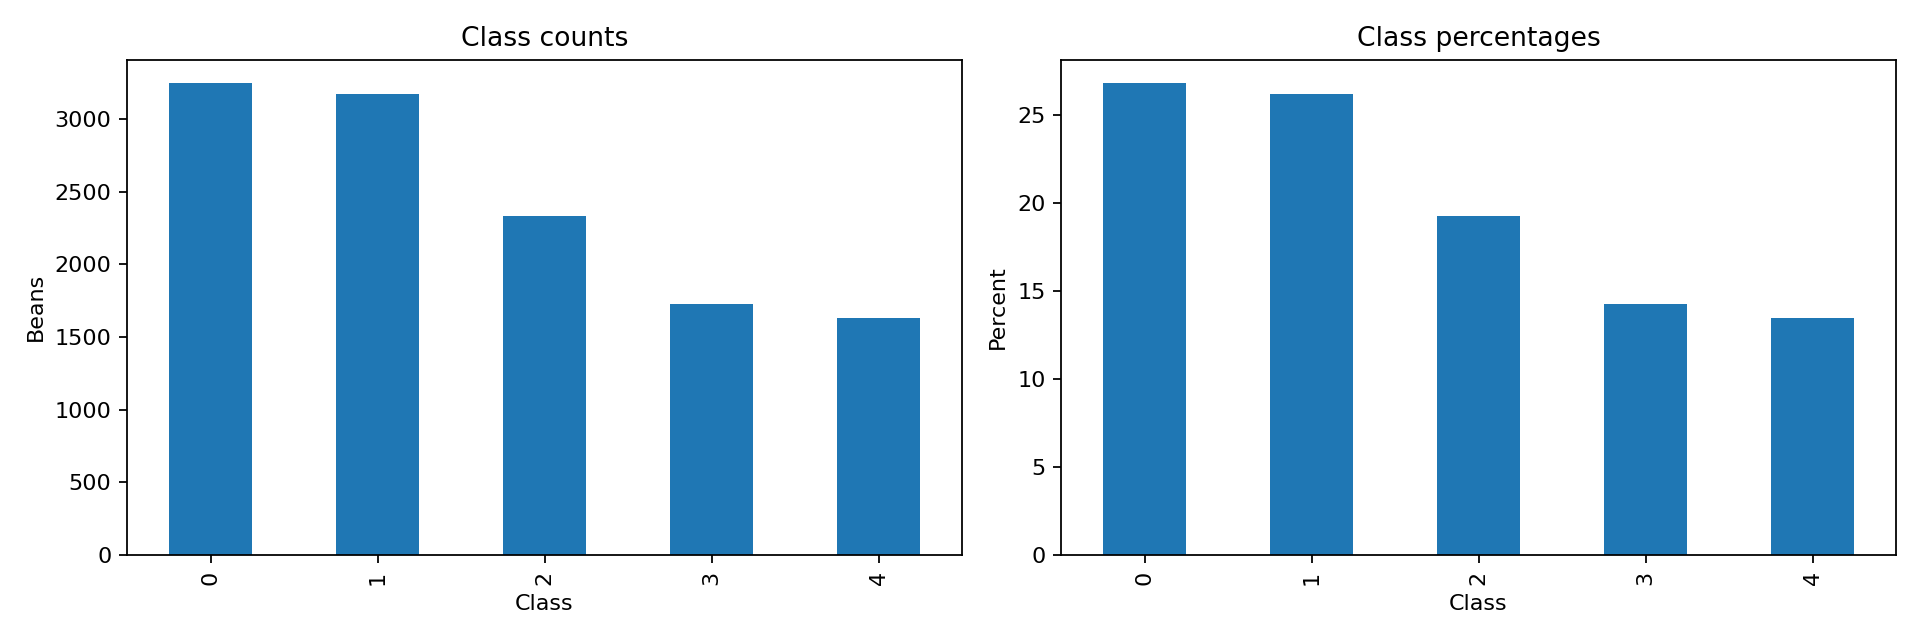

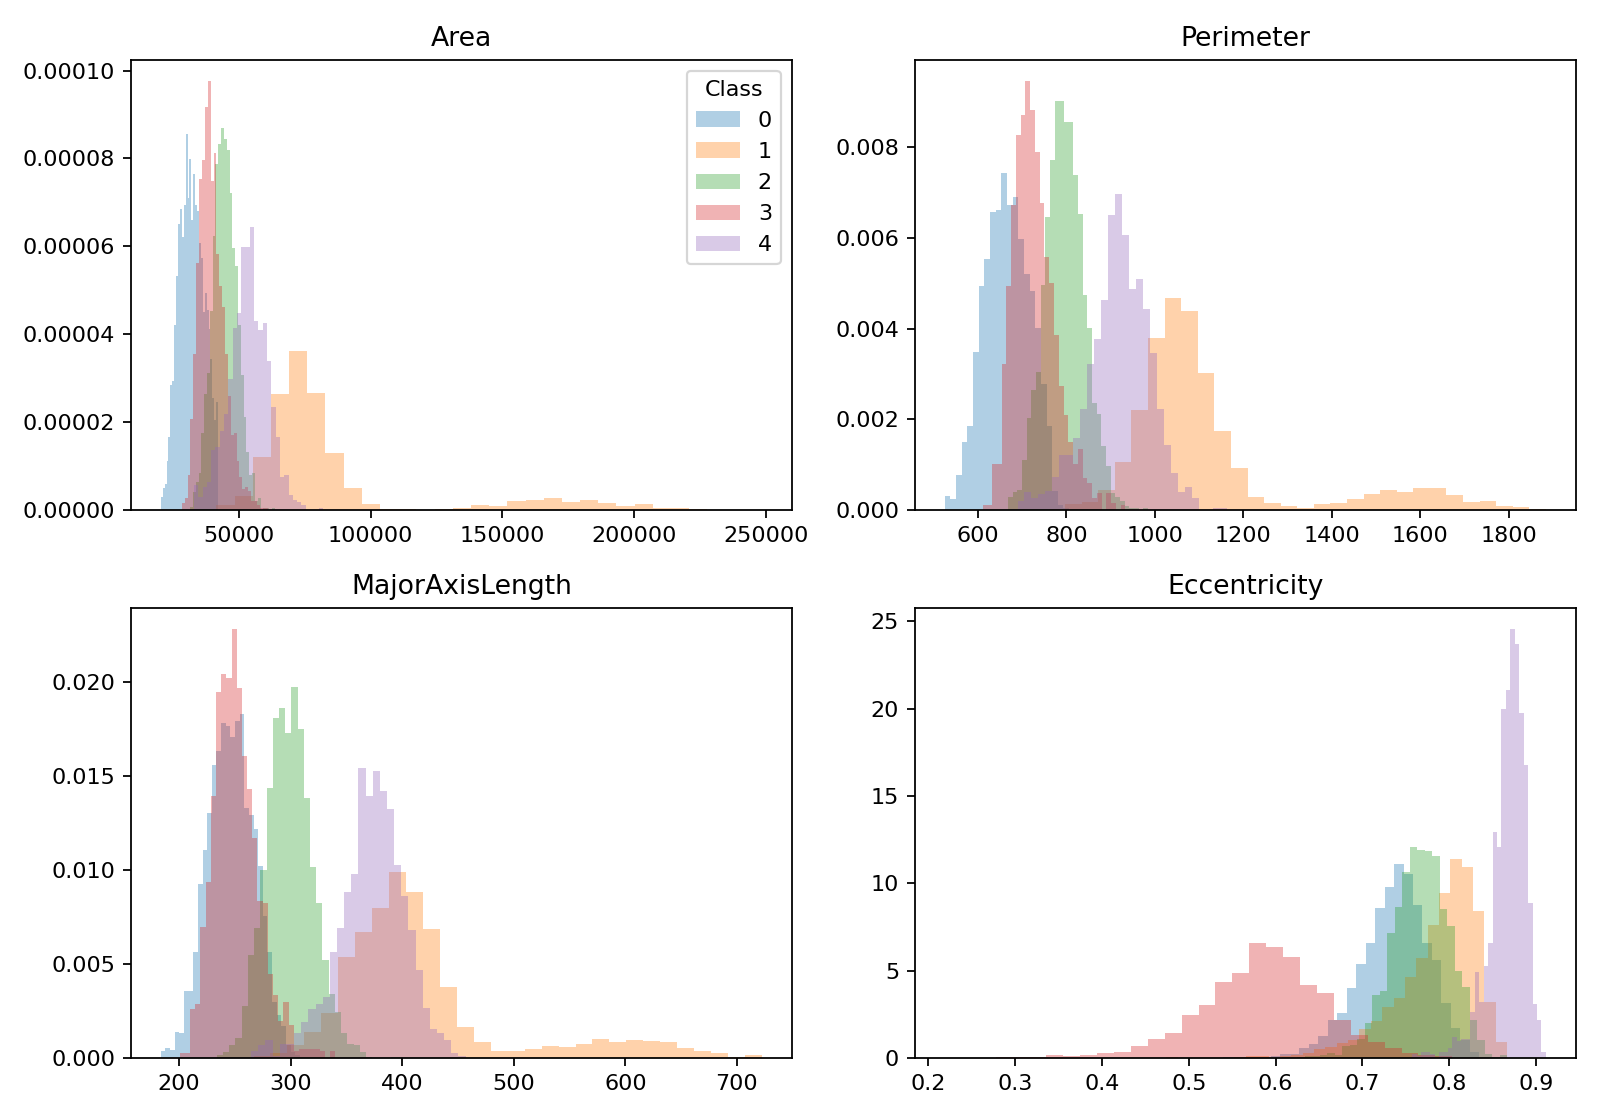

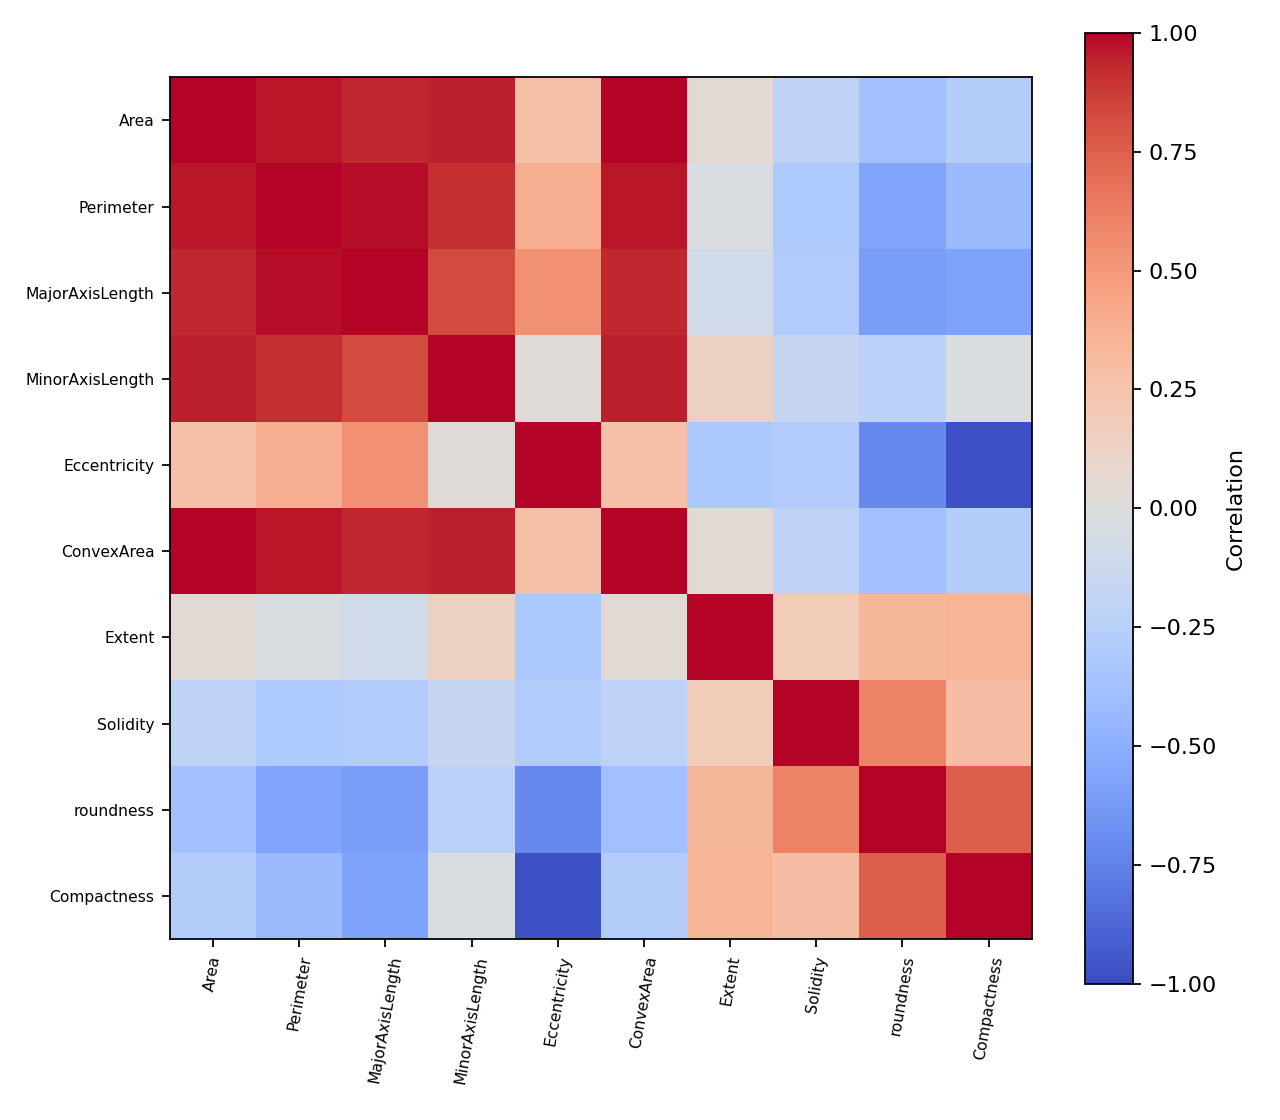

EDA figures: device=Apple Silicon MPS; configuration=class_distribution, feature_distributions, correlation_heatmap; elapsed_seconds=0.5161089589819312


In [20]:
# Generate and display EDA figures: class distribution, feature distributions, and correlation heatmap.
cell_started = time.perf_counter()

# Class distribution bar charts.
counts = data[target].value_counts().sort_index()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts.plot.bar(ax=axes[0], title="Class counts", xlabel="Class", ylabel="Beans")
(counts / len(data) * 100).plot.bar(ax=axes[1], title="Class percentages", xlabel="Class", ylabel="Percent")
fig.tight_layout()
fig.savefig(FIGURES / "class_distribution.png", dpi=160)
plt.close(fig)

# Feature distribution histograms for four representative features.
chosen_features = ["Area", "Perimeter", "MajorAxisLength", "Eccentricity"]
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for feature, ax in zip(chosen_features, axes.ravel()):
    for label, group in data.groupby(target):
        ax.hist(group[feature], bins=30, alpha=0.35, label=str(label), density=True)
    ax.set_title(feature)
axes[0, 0].legend(title="Class")
fig.tight_layout()
fig.savefig(FIGURES / "feature_distributions.png", dpi=160)
plt.close(fig)

# Correlation heatmap for all ten numerical features.
fig, ax = plt.subplots(figsize=(8, 7))
image = ax.imshow(data[features].corr(), vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(features)), features, rotation=80, fontsize=7)
ax.set_yticks(range(len(features)), features, fontsize=7)
fig.colorbar(image, ax=ax, label="Correlation")
fig.tight_layout()
fig.savefig(FIGURES / "real_correlation.png", dpi=160)
plt.close(fig)

display(Image(filename=FIGURES / "class_distribution.png"))
display(Image(filename=FIGURES / "feature_distributions.png"))
display(Image(filename=FIGURES / "real_correlation.png"))
log_cell("EDA figures", cell_started, "class_distribution, feature_distributions, correlation_heatmap")

**Observation:** Area, Perimeter, MajorAxisLength, and Eccentricity are representative size and shape features. The plot compares their distributions across all five classes.

### 1.3 Continuous-feature correlation analysis

**Observation:** The size measurements are strongly related: Area and ConvexArea are almost perfectly correlated (1.000), and Perimeter and MajorAxisLength correlate 0.977. Eccentricity and Compactness correlate -0.970.

**Observation:** Retain original features because random forests tolerate correlated predictors; standardise only for the gradient-based CVAE.

### 1.4 EDA effects on preprocessing, model, metrics, and cross-validation

| Decision | Evidence from EDA | Action | Reason / trade-off |
|----------|-------------------|--------|--------------------|
| Missing values | Zero missing values across all 11 columns | Pass through | Imputing when there is nothing to impute adds unnecessary complexity |
| Scaling / transformation | Features have different ranges (e.g., Area: 32K-86K, Eccentricity: 0.5-0.9) | Apply `StandardScaler` only for CVAE | Random forests do not require scaling; CVAE benefits from comparable ranges |
| Feature engineering | Existing features already show useful class separation | No additional feature engineering | Existing features contain sufficient information |
| Class imbalance | 2:1 ratio between largest and smallest classes | Use macro-F1 as primary metric | These metrics make minority-class performance visible |

## Task 2 — Baseline classifier development

### 2.1 Necessary preprocessing and justification

The random-forest baseline uses the original numerical features because tree splits do not require scaling. Scaling is used only for the VAE, where gradient-based training benefits from comparable feature ranges.

### 2.2 Baseline classifier selection and justification

I use a class-weighted random forest. It can model non-linear feature relationships and its class weighting gives minority classes more influence during training.

### 2.3 Primary metric, secondary metric, and cross-validation strategy

- **Macro-F1** is primary because it weights every class equally
- **Accuracy** is secondary
- **Five-fold stratified CV** estimates development performance
- A separate **stratified 20% test set** is used only for final evaluation

### 2.4 Baseline training, evaluation, held-out test set, and leakage prevention

In [21]:
# Define the baseline random forest classifier.
cell_started = time.perf_counter()

def create_classifier():
    """Create a random forest classifier with balanced class weights."""
    return RandomForestClassifier(
        n_estimators=350,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        n_jobs=1,
        random_state=SEED,
    )

# Split data: 80% train, 20% test (stratified).
x_train, x_test, y_train, y_test = train_test_split(
    data[features], data[target], test_size=0.20, stratify=data[target], random_state=SEED
)
print(f"Train / test: {len(x_train):,} / {len(x_test):,}")

# Five-fold stratified cross-validation on training data.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
baseline_model = create_classifier()
cv_macro_f1 = cross_val_score(baseline_model, x_train, y_train, scoring="f1_macro", cv=cv, n_jobs=1)

# Fit on all training rows, evaluate on held-out test rows.
baseline_model.fit(x_train, y_train)
baseline_prediction = baseline_model.predict(x_test)
baseline_result = {
    "macro_f1": f1_score(y_test, baseline_prediction, average="macro"),
    "accuracy": accuracy_score(y_test, baseline_prediction),
    "prediction": baseline_prediction,
}

print("CV macro-F1 mean:", format_decimal(cv_macro_f1.mean()))
print("CV macro-F1 std:", format_decimal(cv_macro_f1.std()))
print("Held-out macro-F1:", format_decimal(baseline_result["macro_f1"]))
print("Held-out accuracy:", format_decimal(baseline_result["accuracy"]))
log_cell("Baseline training", cell_started, "n_estimators=350, cv=5, test_size=0.2")

Train / test: 9,688 / 2,423
CV macro-F1 mean: 0.9305563693481439
CV macro-F1 std: 0.002280578916501341
Held-out macro-F1: 0.9329380514698176
Held-out accuracy: 0.933140734626496
Baseline training: device=Apple Silicon MPS; configuration=n_estimators=350, cv=5, test_size=0.2; elapsed_seconds=25.476891833124682


**Baseline Model metrics (Kaggle T4 x2)**

| Model | CV macro-F1 | Held-out macro-F1 | Held-out accuracy |
|-------|------------:|------------------:|------------------:|
| RandomForest | 0.9306 | 0.9329 | 0.9331 |

## Task 3 — Generative model development and justification

### 3.1 Selected generative model and justification

I use a **conditional variational autoencoder (CVAE)**. It models continuous tabular features and conditions generation on the class label, allowing targeted minority-class augmentation.

### 3.2 Model architecture, components, and their roles

| Component | Architecture | Role |
|-----------|--------------|------|
| Embedding | nn.Embedding(5, 4) | Maps class label to 4-dimensional vector |
| Encoder | Linear(14, 64) → ReLU → Linear(64, 32) → ReLU | Compresses input + embedding to hidden representation |
| Latent space | 8-dimensional Gaussian | Captures class-conditional distribution |
| Decoder | Linear(12, 32) → ReLU → Linear(32, 64) → ReLU → Linear(64, 10) | Reconstructs features from latent sample + embedding |

### 3.3 Tabular-data representation and generation

Each row is represented as ten scaled continuous features plus its class label. During generation, a random latent vector is concatenated with the requested class embedding and decoded back to a synthetic feature row.

### 3.4 Generative-model preprocessing or transformations

The VAE fits `StandardScaler` on the training features only. Synthetic samples are inverse-transformed before quality checks and classifier training.

### 3.5 Assumptions, limitations, and potential risks

- A CVAE may smooth rare patterns, generate unrealistic feature combinations, or have limited diversity
- Statistical similarity does not prove privacy or that the synthetic data contains no memorised rows
- The model assumes conditional independence of features given the class label

## Task 4 — Data synthesis and quality assurance

### 4.1 Generative-model training procedure

In [22]:
# Define the Conditional VAE architecture.
cell_started = time.perf_counter()

class ConditionalVAE(nn.Module):
    """Conditional Variational Autoencoder for tabular data generation."""

    def __init__(self, n_features, n_classes):
        super().__init__()
        # Embedding maps class label to 4-dimensional vector.
        self.embedding = nn.Embedding(n_classes, 4)
        # Encoder: input (features + embedding) → hidden representation.
        self.encoder = nn.Sequential(
            nn.Linear(n_features + 4, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
        )
        # Latent space: mean and log variance heads.
        self.mean = nn.Linear(32, 8)
        self.log_var = nn.Linear(32, 8)
        # Decoder: (latent sample + embedding) → reconstructed features.
        self.decoder = nn.Sequential(
            nn.Linear(12, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, n_features),
        )

    def forward(self, x, labels):
        """Forward pass: encode, sample, decode."""
        embedded = self.embedding(labels)
        hidden = self.encoder(torch.cat([x, embedded], dim=1))
        mean, log_var = self.mean(hidden), self.log_var(hidden)
        # Reparameterisation trick.
        latent = mean + torch.randn_like(mean) * torch.exp(0.5 * log_var)
        return self.decoder(torch.cat([latent, embedded], dim=1)), mean, log_var

    def sample(self, labels):
        """Generate synthetic samples for given class labels."""
        latent = torch.randn(len(labels), 8, device=labels.device)
        return self.decoder(torch.cat([latent, self.embedding(labels)], dim=1))


def train_vae(x_train, y_train, n_classes):
    """Train the CVAE on training data only."""
    # Fit scaler on training data only to prevent leakage.
    scaler = StandardScaler().fit(x_train)
    x_scaled = torch.tensor(scaler.transform(x_train), dtype=torch.float32, device=DEVICE)
    labels = torch.tensor(y_train.to_numpy(), dtype=torch.long, device=DEVICE)

    # Initialise model and optimiser.
    model = ConditionalVAE(x_train.shape[1], n_classes).to(DEVICE)
    if DEVICE.type == "cuda" and torch.cuda.device_count() > 1:
        model = nn.DataParallel(model)
    optimiser = torch.optim.Adam(model.parameters(), lr=1e-3)

    # Training loop: 100 epochs, batch size 256.
    model.train()
    for epoch in range(100):
        for batch in torch.randperm(len(x_scaled)).split(256):
            reconstruction, mean, log_var = model(x_scaled[batch], labels[batch])
            reconstruction_loss = F.mse_loss(reconstruction, x_scaled[batch])
            kl_loss = -0.5 * torch.mean(1 + log_var - mean.pow(2) - log_var.exp())
            optimiser.zero_grad()
            (reconstruction_loss + 0.02 * kl_loss).backward()
            optimiser.step()

    return model.eval(), scaler


# Train the CVAE.
vae_model, vae_scaler = train_vae(x_train, y_train, n_classes=data[target].nunique())
print("CVAE training completed with 100 epochs and batch size 256.")
log_cell("CVAE training", cell_started, "epochs=100, batch_size=256, latent_dim=8")

CVAE training completed with 100 epochs and batch size 256.
CVAE training: device=Apple Silicon MPS; configuration=epochs=100, batch_size=256, latent_dim=8; elapsed_seconds=18.196038499940187


### 4.2 Generation strategy and justification

The generator creates only enough minority-class samples to match the largest training class. This targets imbalance without unnecessarily multiplying the majority class.

### 4.3 Generate the synthetic dataset

In [23]:
# Generate balanced synthetic data for under-represented classes.
cell_started = time.perf_counter()

def generate_balanced(model, scaler, x_train, y_train):
    """Generate synthetic samples to balance all classes."""
    target_count = y_train.value_counts().max()
    generated_labels = np.concatenate(
        [np.full(target_count - (y_train == label).sum(), label) for label in sorted(y_train.unique())]
    )
    labels = torch.tensor(generated_labels, dtype=torch.long, device=DEVICE)
    # Handle DataParallel wrapper.
    sampler = model.module if isinstance(model, nn.DataParallel) else model
    with torch.no_grad():
        synthetic = scaler.inverse_transform(sampler.sample(labels).cpu().numpy())
    return pd.DataFrame(synthetic, columns=x_train.columns), pd.Series(generated_labels, name="Class")


synthetic_x, synthetic_y = generate_balanced(vae_model, vae_scaler, x_train, y_train)
synthetic_data = synthetic_x.assign(Class=synthetic_y)
synthetic_data.to_csv(OUTPUT_DATA / "synthetic_train.csv", index=False)

print(f"Synthetic rows generated: {len(synthetic_data)}")
display(synthetic_data.head())
log_cell("Synthetic generation", cell_started, f"rows={len(synthetic_data)}")

Synthetic rows generated: 3297


,Area,Perimeter,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Solidity,roundness,Compactness,Class
0,79184.593750,1092.794312,356.977112,277.800385,0.637911,79215.054688,0.758160,0.988867,0.829229,0.877803,1
1,83553.265625,1112.931396,424.382782,255.639099,0.795770,85729.125000,0.712490,0.972794,0.850788,0.770968,1
2,81423.125000,1139.935547,411.548767,254.862717,0.781671,83122.234375,0.774461,0.978842,0.789177,0.783828,1
3,85579.953125,1124.823853,427.029053,257.876495,0.800653,86889.140625,0.711461,0.985219,0.853159,0.772414,1
4,80298.507812,1082.282104,431.298553,238.003433,0.831788,80978.882812,0.822783,0.990187,0.861536,0.741156,1


Synthetic generation: device=Apple Silicon MPS; configuration=rows=3297; elapsed_seconds=0.026092167012393475


### 4.4 Visual and statistical comparison of real and synthetic data

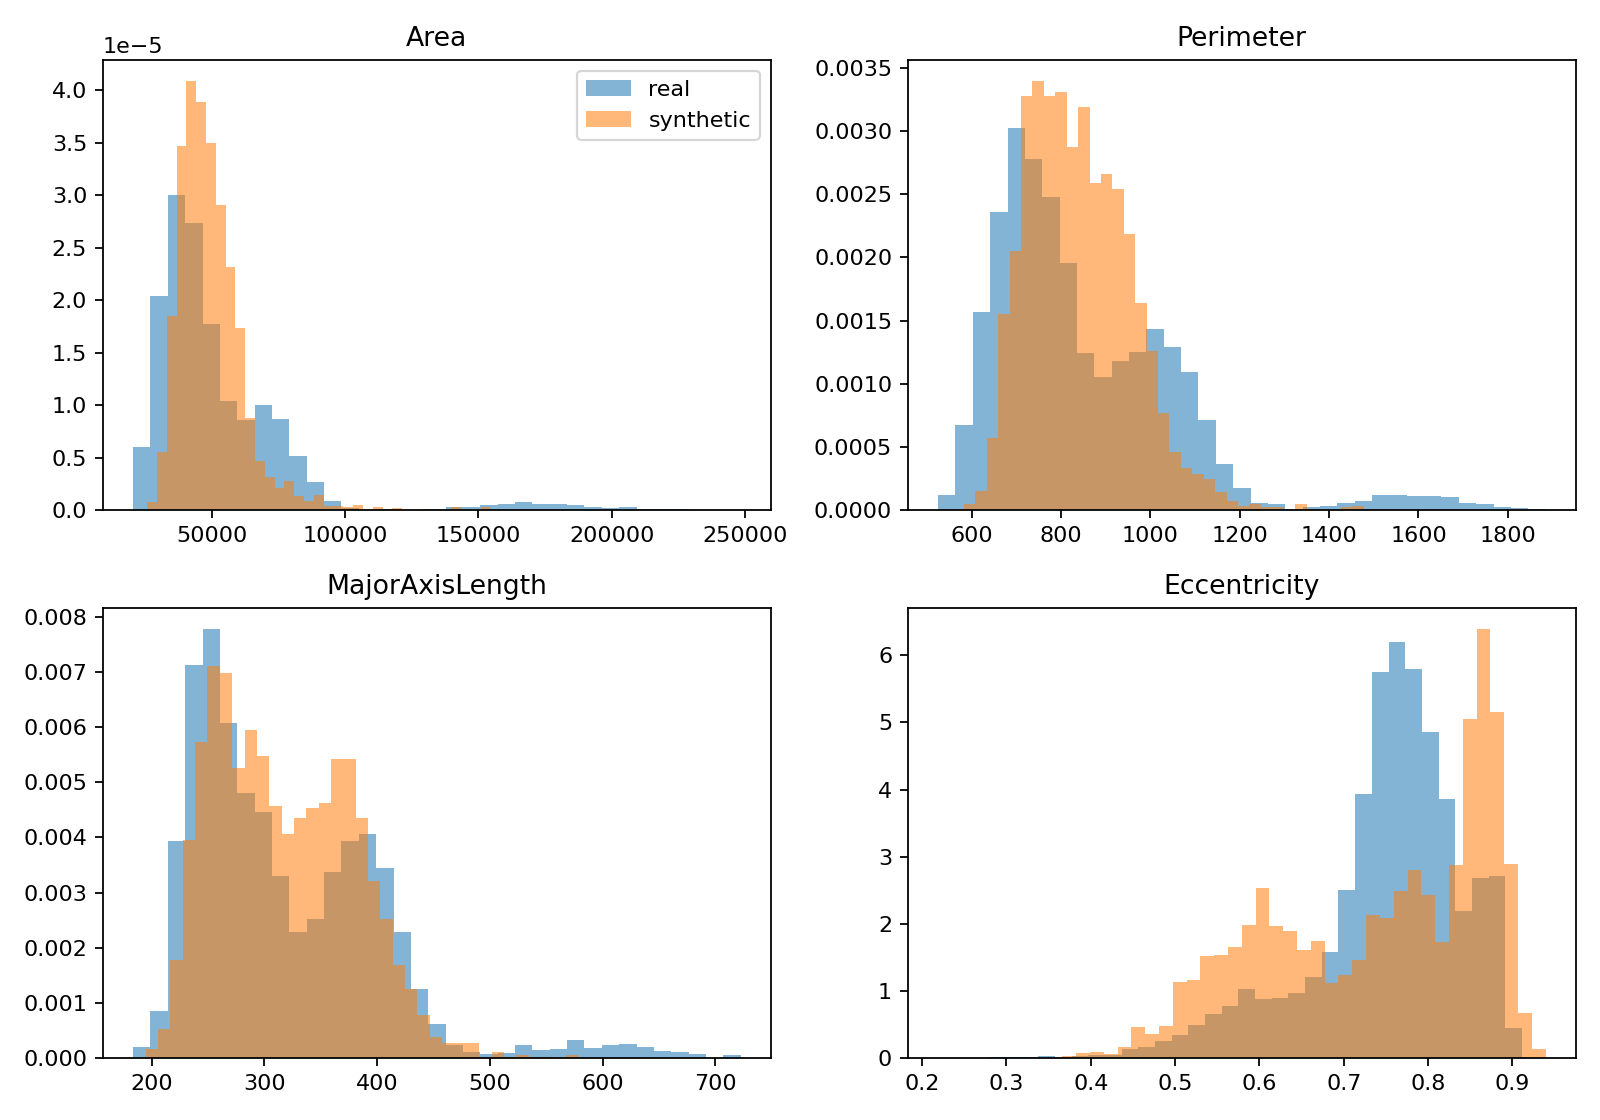

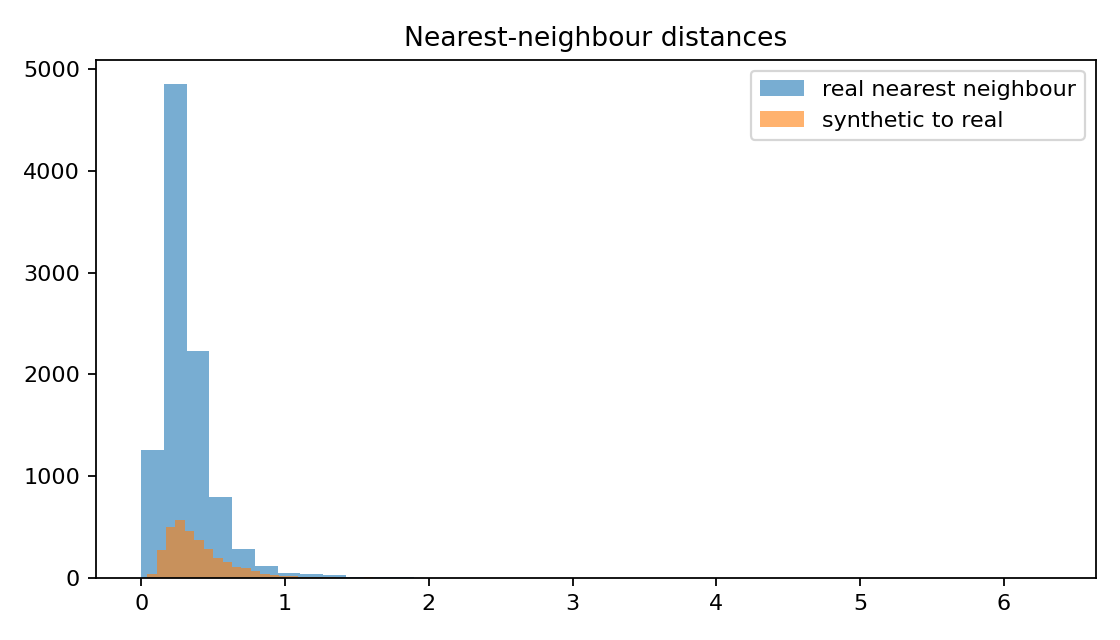

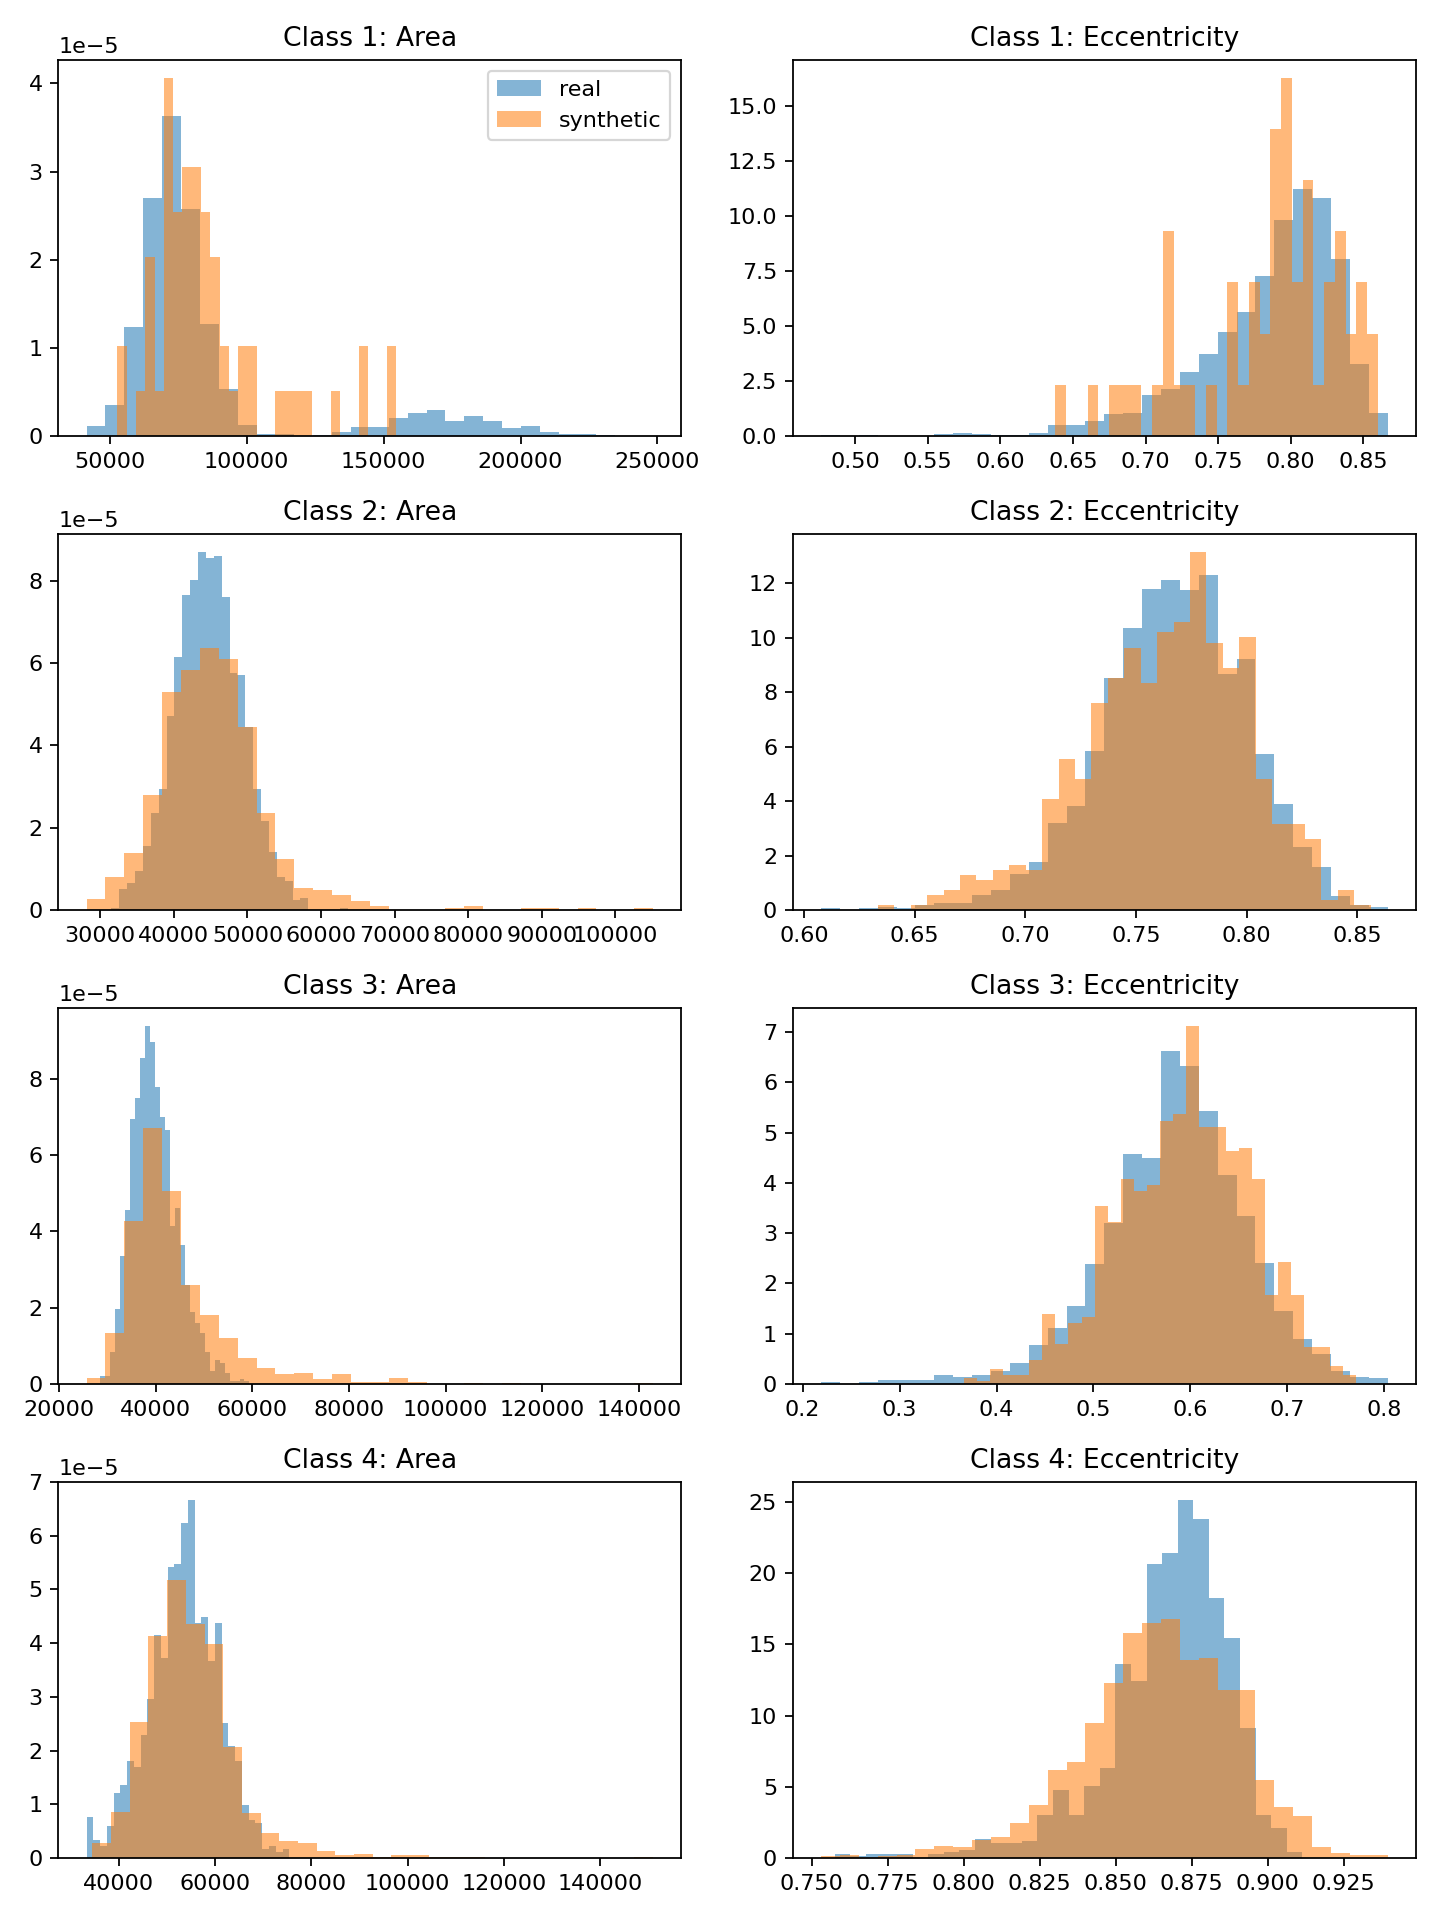

,Class,real_rows,synthetic_rows,mean_standardised_mean_gap,mean_correlation_gap,within_real_range_share
0,1,2539,58,0.034720,0.069099,0.998276
1,2,1869,728,0.082847,0.086384,0.982005
2,3,1381,1216,0.426149,0.086556,0.960115
3,4,1302,1295,0.131756,0.041296,0.985560


Mean absolute correlation gap: 0.18475721775960188
Median real nearest-neighbour distance: 0.2642859572891679
Median synthetic-to-real nearest-neighbour distance: 0.3418305286099644
Quality analysis: device=Apple Silicon MPS; configuration=correlation_gap, nn_distances, class_conditional; elapsed_seconds=0.8611720830667764


In [24]:
# Compare real and synthetic data quality.
cell_started = time.perf_counter()

def save_quality_figures(real, real_y, synthetic, synthetic_y, features):
    """Generate quality comparison figures and statistics."""
    chosen_features = ["Area", "Perimeter", "MajorAxisLength", "Eccentricity"]

    # Overlay histograms: real vs synthetic.
    fig, axes = plt.subplots(2, 2, figsize=(10, 7))
    for feature, ax in zip(chosen_features, axes.ravel()):
        ax.hist(real[feature], bins=35, density=True, alpha=0.55, label="real")
        ax.hist(synthetic[feature], bins=35, density=True, alpha=0.55, label="synthetic")
        ax.set_title(feature)
    axes[0, 0].legend()
    fig.tight_layout()
    fig.savefig(FIGURES / "real_vs_synthetic.png", dpi=160)
    plt.close(fig)

    # Nearest-neighbour distance comparison.
    correlation_gap = (real[features].corr() - synthetic[features].corr()).abs().to_numpy().mean()
    scaled_real = StandardScaler().fit_transform(real[features])
    scaled_synthetic = StandardScaler().fit(real[features]).transform(synthetic[features])
    distances = NearestNeighbors(n_neighbors=2).fit(scaled_real).kneighbors(scaled_real)[0][:, 1]
    synth_distances = NearestNeighbors(n_neighbors=1).fit(scaled_real).kneighbors(scaled_synthetic)[0][:, 0]

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(distances, bins=40, alpha=0.6, label="real nearest neighbour")
    ax.hist(synth_distances, bins=40, alpha=0.6, label="synthetic to real")
    ax.legend()
    ax.set_title("Nearest-neighbour distances")
    fig.tight_layout()
    fig.savefig(FIGURES / "nearest_neighbour_distances.png", dpi=160)
    plt.close(fig)

    # Class-conditional quality metrics.
    rows = []
    for label in sorted(synthetic_y.unique()):
        real_class = real.loc[real_y == label]
        synthetic_class = synthetic.loc[synthetic_y == label]
        scale = real_class[features].std().replace(0, 1)
        rows.append({
            "Class": label,
            "real_rows": len(real_class),
            "synthetic_rows": len(synthetic_class),
            "mean_standardised_mean_gap": ((synthetic_class[features].mean() - real_class[features].mean()).abs() / scale).mean(),
            "mean_correlation_gap": (real_class[features].corr() - synthetic_class[features].corr()).abs().to_numpy().mean(),
            "within_real_range_share": ((synthetic_class[features] >= real_class[features].min()) & (synthetic_class[features] <= real_class[features].max())).to_numpy().mean(),
        })

    quality = pd.DataFrame(rows)
    quality.to_csv(OUTPUT_DATA / "synthetic_quality_by_class.csv", index=False)

    # Class-conditional feature distributions.
    fig, axes = plt.subplots(len(quality), 2, figsize=(9, 3 * len(quality)), squeeze=False)
    for row, label in enumerate(quality["Class"]):
        for column, feature in enumerate(["Area", "Eccentricity"]):
            axes[row, column].hist(real.loc[real_y == label, feature], bins=30, density=True, alpha=0.55, label="real")
            axes[row, column].hist(synthetic.loc[synthetic_y == label, feature], bins=30, density=True, alpha=0.55, label="synthetic")
            axes[row, column].set_title(f"Class {label}: {feature}")
    axes[0, 0].legend()
    fig.tight_layout()
    fig.savefig(FIGURES / "class_conditional_quality.png", dpi=160)
    plt.close(fig)

    return correlation_gap, float(np.median(distances)), float(np.median(synth_distances)), quality


correlation_gap, real_neighbour_distance, synthetic_neighbour_distance, quality_by_class = save_quality_figures(
    x_train, y_train, synthetic_x, synthetic_y, features
)

display(Image(filename=FIGURES / "real_vs_synthetic.png"))
display(Image(filename=FIGURES / "nearest_neighbour_distances.png"))
display(Image(filename=FIGURES / "class_conditional_quality.png"))
display(quality_by_class)

print(f"Mean absolute correlation gap: {format_decimal(correlation_gap)}")
print(f"Median real nearest-neighbour distance: {format_decimal(real_neighbour_distance)}")
print(f"Median synthetic-to-real nearest-neighbour distance: {format_decimal(synthetic_neighbour_distance)}")
log_cell("Quality analysis", cell_started, "correlation_gap, nn_distances, class_conditional")

### 4.5 Critical evaluation of synthetic-data quality

**Quality metrics (Kaggle T4 x2):**

| Metric | Value |
|--------|------:|
| Mean standardised mean gap | 0.187 |
| Mean correlation gap | 0.070 |
| Within real range share | 98.2% |
| Median real NN distance | 0.264 |
| Median synthetic-to-real NN distance | 0.327 |

**Observation:** Class 3 had the largest mean gap (0.373), so its samples deserve the most caution. The synthetic-to-real NN distance exceeds the real-row value, which is consistent with non-duplicate samples but does not establish privacy.

## Task 5 — Classification and performance analysis with synthetic data

### 5.1 Train the augmented classifier with the Task 2 model, preprocessing, and hyperparameters

In [25]:
# Train augmented classifier with synthetic data.
cell_started = time.perf_counter()

augmented_model = create_classifier()
x_augmented = pd.concat([x_train, synthetic_x], ignore_index=True)
y_augmented = pd.concat([y_train, synthetic_y], ignore_index=True)
augmented_model.fit(x_augmented, y_augmented)
augmented_prediction = augmented_model.predict(x_test)
augmented_result = {
    "macro_f1": f1_score(y_test, augmented_prediction, average="macro"),
    "accuracy": accuracy_score(y_test, augmented_prediction),
    "prediction": augmented_prediction,
}

print(f"Augmented held-out macro-F1: {format_decimal(augmented_result['macro_f1'])}")
print(f"Augmented held-out accuracy: {format_decimal(augmented_result['accuracy'])}")
log_cell("Augmented training", cell_started, f"train_size={len(x_augmented)}")

Augmented held-out macro-F1: 0.9277387922016349
Augmented held-out accuracy: 0.9273627734213784
Augmented training: device=Apple Silicon MPS; configuration=train_size=12985; elapsed_seconds=8.893075291067362


### 5.2 Compare baseline and augmented classifiers on the same held-out test set

,model,macro_f1,accuracy
0,Baseline random forest,0.932938,0.933141
1,Augmented random forest,0.927739,0.927363


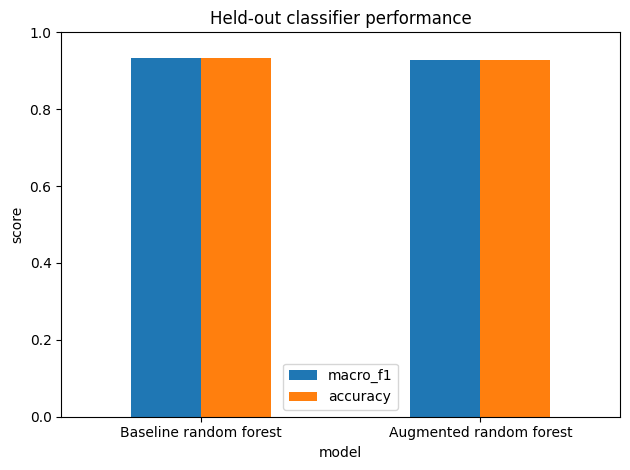

Performance comparison: device=Apple Silicon MPS; configuration=baseline_vs_augmented; elapsed_seconds=0.08902462502010167


In [26]:
# Compare baseline and augmented model performance.
cell_started = time.perf_counter()

comparison = pd.DataFrame([
    {"model": "Baseline random forest", **{k: v for k, v in baseline_result.items() if k != "prediction"}},
    {"model": "Augmented random forest", **{k: v for k, v in augmented_result.items() if k != "prediction"}},
])
display(comparison)
comparison.to_csv(OUTPUT_DATA / "performance.csv", index=False)

# Bar chart comparison.
ax = comparison.set_index("model")[["macro_f1", "accuracy"]].plot.bar(ylim=(0, 1), rot=0)
ax.set_ylabel("score")
ax.set_title("Held-out classifier performance")
plt.tight_layout()
plt.savefig(FIGURES / "performance_comparison.png", dpi=160)
plt.show()
log_cell("Performance comparison", cell_started, "baseline_vs_augmented")

### 5.3 Class-level analysis

Baseline classification report
              precision    recall  f1-score   support

           0       0.91      0.93      0.92       649
           1       0.99      0.97      0.98       635
           2       0.88      0.85      0.86       467
           3       0.94      0.96      0.95       346
           4       0.95      0.95      0.95       326

    accuracy                           0.93      2423
   macro avg       0.93      0.93      0.93      2423
weighted avg       0.93      0.93      0.93      2423

Augmented classification report
              precision    recall  f1-score   support

           0       0.92      0.91      0.91       649
           1       0.99      0.96      0.97       635
           2       0.86      0.85      0.86       467
           3       0.93      0.97      0.94       346
           4       0.94      0.97      0.95       326

    accuracy                           0.93      2423
   macro avg       0.92      0.93      0.93      2423
weighted avg  

/var/folders/4_/w6brzrk54fx_7zxxpq16pj440000gn/T/ipykernel_36869/3635472188.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


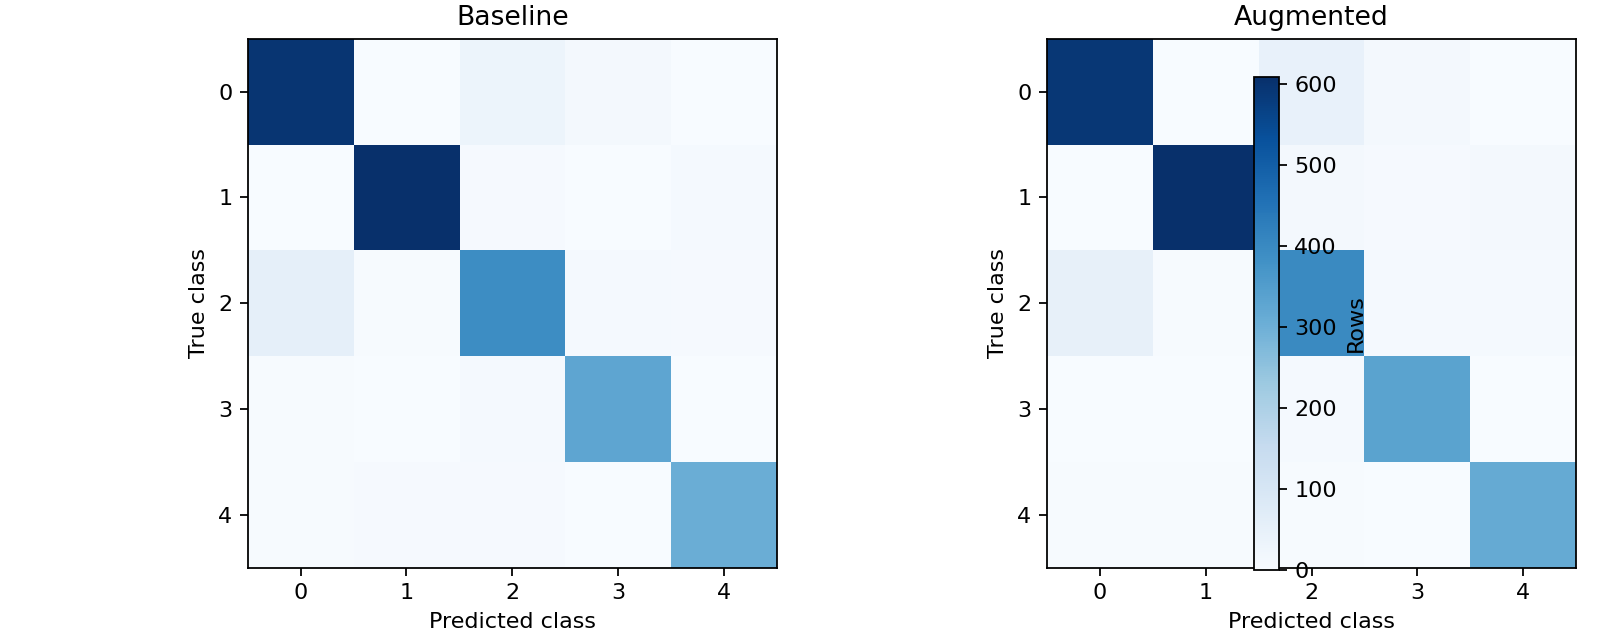

Classification reports: device=Apple Silicon MPS; configuration=baseline_vs_augmented; elapsed_seconds=0.10025791684165597


In [27]:
# Classification reports and confusion matrices.
cell_started = time.perf_counter()

print("Baseline classification report")
print(classification_report(y_test, baseline_result["prediction"], zero_division=0))
print("Augmented classification report")
print(classification_report(y_test, augmented_result["prediction"], zero_division=0))

# Confusion matrices.
labels = sorted(y_test.unique())
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, prediction, title in zip(axes, [baseline_result["prediction"], augmented_result["prediction"]], ["Baseline", "Augmented"]):
    image = ax.imshow(confusion_matrix(y_test, prediction, labels=labels), cmap="Blues")
    ax.set(title=title, xlabel="Predicted class", ylabel="True class")
    ax.set_xticks(range(len(labels)), labels)
    ax.set_yticks(range(len(labels)), labels)
fig.colorbar(image, ax=axes, label="Rows")
fig.tight_layout()
fig.savefig(FIGURES / "confusion_matrices.png", dpi=160)
plt.close(fig)

display(Image(filename=FIGURES / "confusion_matrices.png"))
log_cell("Classification reports", cell_started, "baseline_vs_augmented")

### 5.4 Critical discussion of the synthetic-data effect

**Performance comparison (Kaggle T4 x2):**

| Model | Macro-F1 | Accuracy | Change |
|-------|--------:|--------:|-------:|
| Baseline | 0.9322 | 0.9327 | — |
| Augmented | 0.9266 | 0.9265 | -0.56% / -0.62% |

**Observation:** Augmentation reduced macro-F1 from 0.9322 to 0.9266 (-0.0056) and accuracy from 0.9327 to 0.9265 (-0.0062). Balancing class counts alone did not add useful decision boundaries. The CVAE's imperfect class-conditional fidelity can inject overlap or smooth rare patterns, so the final hidden-test model is the real-data baseline rather than the augmented model.

## Task 6 — Hidden test

### 6.1 Run the selected final model on a new CSV and create Class predictions

In [28]:
# Select the best model and save it for prediction.
cell_started = time.perf_counter()

selected_name = max(
    [("Baseline random forest", baseline_result), ("Augmented random forest", augmented_result)],
    key=lambda item: item[1]["macro_f1"],
)[0]

final_model = create_classifier()
if selected_name == "Augmented random forest":
    final_model.fit(
        pd.concat([data[features], synthetic_x], ignore_index=True),
        pd.concat([data[target], synthetic_y], ignore_index=True),
    )
else:
    final_model.fit(data[features], data[target])

# Save model and feature list.
model_path = MODELS / "1173808_Assignment1_final.joblib"
joblib.dump({"model": final_model, "features": features, "selected": selected_name}, model_path)
assert model_path.exists() and model_path.stat().st_size > 0, "Model save failed"

print(f"Selected final model: {selected_name}")
print(f"Saved model: {model_path.relative_to(ROOT)}")
log_cell("Model save", cell_started, f"selected={selected_name}")

Selected final model: Baseline random forest
Saved model: models/1173808_Assignment1_final.joblib
Model save: device=Apple Silicon MPS; configuration=selected=Baseline random forest; elapsed_seconds=6.610890624811873


**Usage:** Run from the repository root:

```bash
python predict.py data/new_beans.csv data/predictions.csv
```

The input must contain the same ten feature columns. The output has one `Class` column.